# Prediction quality by class stratum: m/z window, evidence regime and support

This notebook connects trained-head performance to the ion groups described in
`part_0_1`/`part_0_2` (kept, unrelated parameter-selection notebooks this campaign
reuses directly). It separates historical population descriptions from groups derived
exclusively from training data, breaks prediction quality down by 100 Da m/z window and
by evidence regime, and closes with the per-class generalization gap between training
and held-out performance — the local, per-class counterpart to `part_4`'s macro
generalization-gap section.

## Introduction

A pooled macro AP (`part_4`) can conceal opposite responses of rare, common and largely
undetectable ions, or of one part of the m/z axis against another. Grouped evaluation
identifies which classes benefit from each condition and whether a gain is specific to
classes that are easy to separate by the spectral evidence rule, on **every** ranking
metric this campaign reports (`average_precision`, `roc_auc`, `ap_above_prevalence`) —
not average precision alone, so a metric-specific effect does not hide in an unplotted
column — and, for the 17 of 20 conditions `part_4` classifies as threshold-anchored, on
the same macro/micro precision/recall/F1/Hamming-loss family `part_4` reports at
campaign scope, broken down by the same strata instead.

### Assumptions

- Historical `part0_*` groups describe the full annotated population, including
  held-out pixels; they are descriptive strata, not inputs to head selection. Their
  saved threshold is retained explicitly and need not equal the training threshold.
- Train-only groups (`train_regime`, `train_support`) use the same definitions at the
  campaign's own evidence threshold.
- Every join is by exact `class_name`, never by row position. Seed pairs, rather than
  classes or pixels, are the units for intervals.
- Rare/common/undetectable membership is mutually exclusive; the different grouping
  dimensions (m/z window, regime, support) overlap and their results are not
  independent tests of the same thing.
- The ion's chemical/molecule class from an external reference database is **not
  computed here**: no source has been selected for this campaign's annotation
  vocabulary; it is separate, explicitly tracked work, not approximated in its
  absence.

### Notation

For ion $c$, $P_c, N_c, U_c$ are training state counts; prevalence is
$P_c/(P_c+N_c+U_c)$. $\mathrm{AP}_c$ is the class-specific average precision under a
given population. A stratum is a fixed set of class identities shared by every model.
The threshold-based family (precision, recall, F1, their micro pooled counterparts and
Hamming loss) uses the same $\sigma(\mathrm{score}) \geq 0.5$ decision and formulas as
`part_4`'s own Notation section, applied per stratum instead of over the whole
campaign; only conditions `part_4` classifies as threshold-anchored carry a value
there, every other condition is `nan`.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.analysis.autoencoder.heads.class_stratification import class_strata, stratified_metrics
from msi_autoencoder_wrapper.analysis.autoencoder.heads.predictive_comparison import generalization_gaps
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("prediction_local")

from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)


2026-09-19 23:45:02,026 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-19 23:45:02,029 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-19 23:45:02,407 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-19 23:45:02,409 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-19 23:45:02,417 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-19 23:45:02,419 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 46 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-19 23:45:02,436 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-19 23:45:02,451 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-19 23:45:02,452 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 33 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration

## Producing the tables this notebook reads

### Methodology

#### Implementation

No new precompute routine backs this notebook: `per_class`, `probe_per_class` and
`prediction` (the last used only for the m/z-window threshold heatmap's full-range
column) are already written by the base full-campaign inference cache; the class
strata come from the kept `part_0_1`/`part_0_2` notebooks' own exported CSVs, in this
same folder. This notebook only joins and aggregates tables already on disk.

### Remarks

### Notes

In [2]:
SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/analysis_settings.yaml")
NOTEBOOK_DIR = SETTINGS_PATH.parent
RESULTS = NOTEBOOK_DIR / "part_6_prediction_local_results"
ANNOTATION_RESULTS_DIR = NOTEBOOK_DIR
RESULTS.mkdir(exist_ok=True)

settings = campaign.load_settings(SETTINGS_PATH)
settings["settings_path"] = str(SETTINGS_PATH)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)
models = load_model_catalog(settings)
CONDITION_ORDER = reports.condition_order(models)

theme = load_visualization_theme(settings)
theme.apply()
LABEL_COLOR = {label: theme.color_for_model(label, index) for index, label in enumerate(CONDITION_ORDER)}

# --- embedded figure resolution --------------------------------------------
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------


def violin_panel(frame, *, group_column, order, colors, ax, ylabel, title):
    """Draw one violin per group value present in `frame`, contractive-style."""
    present = [value for value in order if value in set(frame[group_column])]
    for position, value in enumerate(present):
        values = frame.loc[frame[group_column] == value, "value"].dropna().to_numpy()
        if not len(values):
            continue
        plot_violin_with_points(values, position=position, ax=ax, width=0.7, color=colors[value],
                                point_size=8.0, jitter=0.10, theme=theme)
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels(present, rotation=45, ha="right", fontsize=7)
    ax.set(ylabel=ylabel, title=title)
    ax.grid(theme.grid_visible, alpha=theme.grid_alpha)


def heatmap_panel(frame, *, index, columns, values, ax, title, column_order=None, value_format="{:.3f}"):
    """Condition-by-stratum heatmap with printed values, contractive-style (no
    ready-made heatmap primitive exists in `visualization.metrics`, so this mirrors
    what `visualization.predictive.heatmap` does, minus that module's theme lookup)."""
    table = frame.pivot_table(index=index, columns=columns, values=values, aggfunc="mean")
    if column_order is not None:
        table = table.reindex(columns=column_order)
    image = ax.imshow(table.to_numpy(dtype=float), aspect="auto", cmap="viridis", interpolation="nearest")
    ax.set_xticks(range(table.shape[1]), list(table.columns), rotation=35, ha="right", fontsize=7)
    ax.set_yticks(range(table.shape[0]), list(table.index), fontsize=7)
    for row in range(table.shape[0]):
        for column in range(table.shape[1]):
            cell = table.to_numpy(dtype=float)[row, column]
            if np.isfinite(cell):
                ax.text(column, row, value_format.format(cell), ha="center", va="center", fontsize=6)
    ax.figure.colorbar(image, ax=ax, label=values)
    ax.grid(False)
    ax.set(title=title)

## Class identity, historical groups and training-only groups

### Methodology

#### Theoretical

The historical `part0_regime` is copied exactly from `class_regimes.csv`: undetectable
if at least 95% of unannotated entries are N; otherwise rare if annotation prevalence
is below 1%; otherwise common. `train_regime` applies those same cut-offs to train-only
state counts at this campaign's own evidence threshold/radius. These groups differ from
train-support bins (0, 1-9, 10-99, 100+ positives). Additional descriptive strata are
part-0 evidence AUC and 100-Da m/z windows.

#### Implementation

Join the part-0 prevalence, regime and evidence-separation tables to cached train
counts using unique class names; require identical complete class catalogues.

#### Figure descriptions

Tables list the taxonomy and counts for each historical-to-training regime
transition. A changed regime does not imply that a class changed biologically:
threshold, population and training sample differ.

### Remarks

### Notes

In [3]:
manifest = json.loads((Path(settings["cache_directory"]) / "latest.json").read_text())
run_directory = Path(manifest["run_directory"])
strata = class_strata(
    pd.read_csv(ANNOTATION_RESULTS_DIR / "part_0_1_annotation_population_results/class_prevalence.csv"),
    pd.read_csv(ANNOTATION_RESULTS_DIR / "part_0_2_evidence_threshold_selection_results/class_regimes.csv"),
    pd.read_csv(ANNOTATION_RESULTS_DIR / "part_0_2_evidence_threshold_selection_results/class_separation.csv"),
    pd.read_csv(run_directory / "train_class_states.csv"),
)
transitions = strata.groupby(["part0_regime", "train_regime"]).size().rename("classes").reset_index()
display(strata)
display(transitions)
reports.save_tables(RESULTS, class_strata=strata, regime_transitions=transitions)

2026-09-19 23:45:02,546 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.heads.class_stratification:61 | Joined 508 class identities to historical and train-only strata.


,class_name,positive_entries,negative_entries,uncertain_entries,relative_threshold,bin_radius,mz,part0_prevalence,part0_regime,part0_threshold,part0_radius,part0_negative_fraction,evidence_auc,train_prevalence,train_negative_fraction,train_regime,train_support,part0_evidence_separation,mz_window
0,C10H12N2O5|-H,20,19742,13888,0.0119,1,239.067345,0.000442,rare,0.0119,1,0.588171,0.683112,0.000594,0.587035,rare,10-99 positives,0.5 < AUC <= 0.7,200-300 m/z
1,C10H12N4O5|-H,218,6245,27187,0.0119,1,267.073493,0.006502,rare,0.0119,1,0.187058,0.738700,0.006478,0.186797,rare,100+ positives,AUC > 0.7,200-300 m/z
2,C10H13N4O8P|-H,6306,4959,22385,0.0119,1,347.039824,0.186702,common,0.0119,1,0.179169,0.500128,0.187400,0.181356,common,100+ positives,0.5 < AUC <= 0.7,300-400 m/z
3,C10H14N4O5|-H,1276,16917,15457,0.0119,1,269.089143,0.037554,common,0.0119,1,0.522774,0.678259,0.037920,0.522549,common,100+ positives,0.5 < AUC <= 0.7,200-300 m/z
4,C10H14N5O7P|-H,6698,3995,22957,0.0119,1,346.055808,0.199138,common,0.0119,1,0.147788,0.326039,0.199049,0.148226,common,100+ positives,AUC <= 0.5,300-400 m/z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,C9H16N6O2|-H,30,19751,13869,0.0119,1,239.126197,0.000806,rare,0.0119,1,0.588489,0.802910,0.000892,0.587478,rare,10-99 positives,AUC > 0.7,200-300 m/z
504,C9H16O9|-H,208,6245,27197,0.0119,1,267.072156,0.006305,rare,0.0119,1,0.187020,0.736068,0.006181,0.186741,rare,100+ positives,AUC > 0.7,200-300 m/z
505,C9H17NO4|-H,13,20768,12869,0.0119,1,202.108482,0.000247,rare,0.0119,1,0.618117,0.769174,0.000386,0.617415,rare,10-99 positives,AUC > 0.7,200-300 m/z
506,C9H17NO5|-H,1028,20386,12236,0.0119,1,218.103396,0.030978,common,0.0119,1,0.625610,0.422084,0.030550,0.624916,common,100+ positives,AUC <= 0.5,200-300 m/z


,part0_regime,train_regime,classes
0,common,common,310
1,rare,common,5
2,rare,rare,193


2026-09-19 23:45:02,579 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:345 | Saved 2 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/part_6_prediction_local_results.


## Stratified ranking and paired baseline effects

### Methodology

#### Theoretical

Within each model, split, evaluation population and fixed class stratum, calculate the
unweighted mean of eligible per-class metrics. Eligibility is inherited from `part_4`'s
own ranking analysis: positive training support and both positive and comparison-zero
evaluation examples. Baseline effects are differences of matched-stratum macro means
for the same derived seed and compatible data/backbone/training configuration.

#### Implementation

Average duplicate tasks within each seed before comparing; retain pairs involving
`vpu_precision_sweep`. Intervals reflect variation across at most five seeds and are
exploratory. Both validation and test are exported; plots focus on validation.

#### Figure descriptions

For each grouping and stratum: x=condition, y=validation average precision; each
overlaid point is one seed, the violin includes every available seed. The paired-effect
table reports left-minus-right value, its interval and the number of matched seeds.

### Remarks

### Notes

In [4]:
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)
per_class = select_catalog_frame(cache.load_table(settings, "per_class"), models)
enriched, grouped = stratified_metrics(per_class, strata)
KEYS = ["split", "population", "grouping", "stratum", "metric"]
units = reports.experimental_units(grouped, models, KEYS)
differences, contrasts = reports.paired_comparisons(units, KEYS)
baseline = reports.baseline_contrasts(contrasts, models)
split_summary = units.groupby(["label", "split", "population", "grouping", "stratum", "metric"]).value.agg(
    mean="mean", std="std", seeds="count").reset_index()
display(split_summary.query("metric == 'average_precision' and population == 'annotation_retrieval' and grouping == 'part0_regime'"))
display(grouped[["grouping", "stratum", "split", "population", "total_classes", "eligible_classes"]].drop_duplicates())
display(baseline.query("split == 'validation' and metric == 'average_precision' and population == 'annotation_retrieval'"))

plot_data = units.query("split == 'validation' and population == 'annotation_retrieval' and metric == 'average_precision'")
for (grouping, stratum), frame in plot_data.groupby(["grouping", "stratum"]):
    filename = f"{grouping}_{stratum}".replace("/", "_").replace(" ", "_").replace("<", "lt").replace(">", "gt")
    figure, axis = plt.subplots(figsize=(max(8.0, 1.3 * frame.label.nunique()), 5.0), dpi=theme.figure_dpi)
    violin_panel(frame, group_column="label", order=CONDITION_ORDER, colors=LABEL_COLOR, ax=axis,
                ylabel="validation average precision", title=f"Validation AP: {grouping} / {stratum}")
    figure.tight_layout()
    figure.savefig(RESULTS / f"{filename}.png")
    plt.close("all")
reports.save_tables(RESULTS, per_class_stratified=enriched, grouped_metrics=grouped, experimental_units=units,
                    paired_differences=differences, baseline_contrasts=baseline, split_summary=split_summary)

2026-09-19 23:45:12,030 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:203 | Oriented 48 baseline contrasts as candidate minus reference.


,label,split,population,grouping,stratum,metric,mean,std,seeds
101,"VPU + contractive + contrastive (T=0.07, w=0.001)",test,annotation_retrieval,part0_regime,common,average_precision,0.839598,0.007852,5
111,"VPU + contractive + contrastive (T=0.07, w=0.001)",test,annotation_retrieval,part0_regime,rare,average_precision,0.432796,0.007833,5
441,"VPU + contractive + contrastive (T=0.07, w=0.001)",train,annotation_retrieval,part0_regime,common,average_precision,0.839859,0.008137,5
451,"VPU + contractive + contrastive (T=0.07, w=0.001)",train,annotation_retrieval,part0_regime,rare,average_precision,0.404087,0.007563,5
781,"VPU + contractive + contrastive (T=0.07, w=0.001)",validation,annotation_retrieval,part0_regime,common,average_precision,0.840413,0.008507,5
...,...,...,...,...,...,...,...,...,...
15411,"VPU + contrastive (T=0.30, w=0.01, j=0.5)",test,annotation_retrieval,part0_regime,rare,average_precision,0.437542,0.020451,5
15741,"VPU + contrastive (T=0.30, w=0.01, j=0.5)",train,annotation_retrieval,part0_regime,common,average_precision,0.837882,0.007035,5
15751,"VPU + contrastive (T=0.30, w=0.01, j=0.5)",train,annotation_retrieval,part0_regime,rare,average_precision,0.408903,0.013159,5
16081,"VPU + contrastive (T=0.30, w=0.01, j=0.5)",validation,annotation_retrieval,part0_regime,common,average_precision,0.839068,0.005720,5


,grouping,stratum,split,population,total_classes,eligible_classes
0,part0_regime,common,test,annotation_retrieval,310,310
1,part0_regime,rare,test,annotation_retrieval,198,198
2,part0_regime,common,test,operational_pn,310,310
3,part0_regime,rare,test,operational_pn,198,198
4,part0_regime,common,train,annotation_retrieval,310,310
...,...,...,...,...,...,...
48037,mz_window,400-500 m/z,validation,operational_pn,44,44
48038,mz_window,500-600 m/z,validation,operational_pn,33,33
48039,mz_window,600-700 m/z,validation,operational_pn,18,18
48040,mz_window,700-800 m/z,validation,operational_pn,81,81


,left,right,left_source,right_source,left_condition,right_condition,split,population,grouping,stratum,metric,pairs,mean_difference,median_difference,positive_pairs,ci_low,ci_high,reason,label,reference


2026-09-19 23:45:29,417 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:345 | Saved 6 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/part_6_prediction_local_results.


## Threshold-based stratified prediction metrics (macro & micro)

### Methodology

#### Theoretical

`average_precision`/`roc_auc`/`ap_above_prevalence` (above) are threshold-free; they
say nothing about a fixed decision boundary. `part_4`'s own campaign-level analysis
reports macro/micro precision, recall, F1 and Hamming loss at a `sigmoid(score) >= 0.5`
cutoff, but only for the 17 of 20 conditions whose training objective's own theory
makes that cutoff a genuine, checkable probability (see `part_4`'s "Threshold-based
prediction metrics" section for the full family-by-family justification; the excluded
3 — `pu_ranking` and the two three-state heads — get `nan` here for the same reason,
not a silently wrong zero). This section reports the same threshold family broken down
by the class strata above instead of pooled over the whole campaign, using both
conventions: macro (the per-class precision/recall/F1 the base cache already computes,
averaged over the stratum's eligible classes) and micro (their confusion counts pooled
over the stratum before dividing), so a macro/micro divergence confined to one stratum
stays visible rather than averaged away.

#### Implementation

`stratified_metrics` (`class_stratification.py`) extends the ranking-metric
aggregation above with the same threshold family: macro precision/recall/F1 from the
per-class ratios `ranking_tables` already computes, and micro precision/recall/F1/
Hamming loss pooled per stratum from the raw `true_positive`/`false_positive`/
`false_negative` counts it also stores (added alongside this notebook so a stratum's
micro metrics need not be re-derived from the macro ratios, which is lossy whenever a
class's precision is exactly 0). Nothing is recomputed here; `grouped`/`units` from the
cell above already carry these rows.

#### Figure descriptions

Table: one row per (condition, `part0_regime` stratum), columns the seven threshold
metrics, population `annotation_retrieval`, validation split, mean over repetitions.
Ineligible conditions show `NaN` in every column.

### Remarks

### Notes

In [5]:
THRESHOLD_METRICS = ["f1", "precision", "recall", "micro_f1", "micro_precision", "micro_recall", "hamming_loss"]

threshold_stratum_summary = (
    units.query("split == 'validation' and population == 'annotation_retrieval' and "
               "grouping == 'part0_regime' and metric in @THRESHOLD_METRICS")
    .groupby(["label", "stratum", "metric"]).value.mean()
    .unstack("metric")[THRESHOLD_METRICS]
    .reset_index()
)
threshold_stratum_summary["label"] = pd.Categorical(threshold_stratum_summary["label"], categories=CONDITION_ORDER, ordered=True)
threshold_stratum_summary = threshold_stratum_summary.sort_values(["label", "stratum"]).set_index(["label", "stratum"])
display(threshold_stratum_summary.round(4))
reports.save_tables(RESULTS, threshold_stratum_summary=threshold_stratum_summary.reset_index())

metric                                                          f1  precision  \
label                                              stratum                      
VPU + contractive + contrastive (T=0.07, w=0.001)  common   0.7179     0.7869   
                                                   rare     0.1168     0.1731   
VPU + contrastive (T=0.01, w=0.001)                common   0.7123     0.7787   
                                                   rare     0.1226     0.1783   
VPU + contrastive (T=0.07, w=0.01)                 common   0.7074     0.7790   
                                                   rare     0.1193     0.1787   
VPU + contrastive (T=0.30, w=0.01)                 common   0.7088     0.7822   
                                                   rare     0.1141     0.1741   
VPU + contractive + contrastive (T=0.07, w=0.00... common   0.7079     0.7778   
                                                   rare     0.1229     0.1765   
VPU + contractive + contrastive (T=0.07, w=0.00... common   0.7137     0.7938   
                                                   rare     0.1179     0.1798   
VPU + contractive + contrastive (T=0.07, w=0.00... common   0.7058     0.7778   
                                                   rare     0.1253     0.1787   
VPU + contrastive (T=0.01, w=0.001, j=0.1)         common   0.7042     0.7775   
                                                   rare     0.1110     0.1673   
VPU + contrastive (T=0.01, w=0.001, j=0.25)        common   0.7062     0.7727   
                                                   rare     0.1237     0.1829   
VPU + contrastive (T=0.01, w=0.001, j=0.5)         common   0.7107     0.7773   
                                                   rare     0.1136     0.1693   
VPU + contrastive (T=0.07, w=0.01, j=0.1)          common   0.7015     0.7667   
                                                   rare     0.1265     0.1761   
VPU + contrastive (T=0.07, w=0.01, j=0.25)         common   0.7041     0.7733   
                                                   rare     0.1230     0.1822   
VPU + contrastive (T=0.07, w=0.01, j=0.5)          common   0.7105     0.7769   
                                                   rare     0.1246     0.1830   
VPU + contrastive (T=0.30, w=0.01, j=0.1)          common   0.7035     0.7751   
                                                   rare     0.1223     0.1781   
VPU + contrastive (T=0.30, w=0.01, j=0.25)         common   0.7044     0.7715   
                                                   rare     0.1222     0.1822   
VPU + contrastive (T=0.30, w=0.01, j=0.5)          common   0.7145     0.7792   
                                                   rare     0.1227     0.1892   

metric                                                      recall  micro_f1  \
label                                              stratum                     
VPU + contractive + contrastive (T=0.07, w=0.001)  common   0.7238    0.8530   
                                                   rare     0.1360    0.3572   
VPU + contrastive (T=0.01, w=0.001)                common   0.7165    0.8537   
                                                   rare     0.1467    0.3667   
VPU + contrastive (T=0.07, w=0.01)                 common   0.7133    0.8507   
                                                   rare     0.1322    0.3647   
VPU + contrastive (T=0.30, w=0.01)                 common   0.7133    0.8509   
                                                   rare     0.1259    0.3601   
VPU + contractive + contrastive (T=0.07, w=0.00... common   0.7139    0.8502   
                                                   rare     0.1408    0.3644   
VPU + contractive + contrastive (T=0.07, w=0.00... common   0.7186    0.8529   
                                                   rare     0.1372    0.3597   
VPU + contractive + contrastive (T=0.07, w=0.00... common   0.7137    0.8509   
                                             

2026-09-19 23:45:29,475 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:345 | Saved 1 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/part_6_prediction_local_results.


## Class-stratified frozen-encoder probe

### Methodology

#### Theoretical

The shared ridge probe predicts annotation indicators from frozen latent codes, fitted
on training data only with a fixed ridge penalty for every model (`part_3`). Applying
the same class strata to its validation/test ranking scores helps distinguish
performance of the trained head from information already accessible through this
common linear readout.

#### Implementation

Reuse `probe_per_class` from the base cache. Apply the same strata/eligibility rules,
then average duplicate tasks. Join head and probe units on condition, actual seeds,
contracts, split, population, grouping, stratum and metric.

#### Figure descriptions

Validation annotation-retrieval probe AP for one historical rare/common stratum;
x-axis the condition, y-axis macro AP within that fixed class group.

### Remarks

An improvement of the trained head without a corresponding probe improvement suggests
a readout-dependent gain, but does not prove the encoder is unchanged.

### Notes

In [6]:
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)
probe_per_class = select_catalog_frame(cache.load_table(settings, "probe_per_class"), models)
_, probe_grouped = stratified_metrics(probe_per_class, strata)
probe_units = reports.experimental_units(probe_grouped, models, KEYS)
comparison_keys = ["source", "condition", "label", *reports.PAIR_KEYS, *KEYS]
head_probe = units.merge(probe_units, on=comparison_keys, suffixes=("_head", "_probe"), validate="one_to_one")
head_probe["head_minus_probe"] = head_probe.value_head - head_probe.value_probe

probe_plot = probe_units.query("split == 'validation' and population == 'annotation_retrieval' and "
                               "metric == 'average_precision' and grouping == 'part0_regime'")
for stratum, frame in probe_plot.groupby("stratum"):
    figure, axis = plt.subplots(figsize=(max(8.0, 1.3 * frame.label.nunique()), 5.0), dpi=theme.figure_dpi)
    violin_panel(frame, group_column="label", order=CONDITION_ORDER, colors=LABEL_COLOR, ax=axis,
                ylabel="probe validation average precision", title=f"Frozen-encoder probe validation AP: {stratum}")
    figure.tight_layout()
    figure.savefig(RESULTS / f"probe_part0_{stratum}.png")
    plt.close("all")
display(head_probe.query("split == 'validation' and population == 'annotation_retrieval' and "
                         "metric == 'average_precision' and grouping == 'part0_regime'")
        [["label", "repetition", "stratum", "value_head", "value_probe", "head_minus_probe"]])
reports.save_tables(RESULTS, probe_grouped_metrics=probe_grouped, probe_experimental_units=probe_units,
                    head_probe_comparison=head_probe)

,label,repetition,stratum,value_head,value_probe,head_minus_probe
441,"VPU + contrastive (T=0.07, w=0.01)",0,common,0.834027,0.687347,0.146680
451,"VPU + contrastive (T=0.07, w=0.01)",0,rare,0.452053,0.239309,0.212744
1121,"VPU + contrastive (T=0.07, w=0.01)",1,common,0.839739,0.715284,0.124455
1131,"VPU + contrastive (T=0.07, w=0.01)",1,rare,0.445135,0.241083,0.204051
1801,"VPU + contrastive (T=0.07, w=0.01)",2,common,0.830559,0.704610,0.125948
...,...,...,...,...,...,...
52811,"VPU + contrastive (T=0.07, w=0.01, j=0.1)",2,rare,0.464019,0.246408,0.217611
53481,"VPU + contrastive (T=0.07, w=0.01, j=0.1)",3,common,0.843185,0.697982,0.145203
53491,"VPU + contrastive (T=0.07, w=0.01, j=0.1)",3,rare,0.464476,0.244351,0.220126
54161,"VPU + contrastive (T=0.07, w=0.01, j=0.1)",4,common,0.837906,0.717847,0.120059


2026-09-19 23:45:37,076 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:345 | Saved 3 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/part_6_prediction_local_results.


## Detailed stratification: m/z windows, on every metric

### Methodology

#### Theoretical

Whether prediction quality varies systematically along the m/z axis, and on which
ranking metric — the contractive-style "one figure per metric" convention from `part_4`
is applied here too, since a condition can rank classes well (`average_precision`) while
separating them poorly at the ROC operating point (`roc_auc`), or vice versa, and a
per-metric heatmap keeps that visible rather than averaged into one number.

A fourth axis belongs here in principle: the ion's chemical/molecule class from an
external reference database. **It is not computed**, for the reason stated in the
Assumptions above.

#### Implementation

Reuses `grouped`/`units` from above; nothing is recomputed. Windows are ordered by
their lower edge. One heatmap panel per metric, stacked vertically in one figure.

#### Figure descriptions

x=window ordered by lower edge, y=condition, cell=validation macro value of that
metric, one panel per metric (`average_precision`, `roc_auc`, `ap_above_prevalence`),
stacked top to bottom in one figure.

### Remarks

### Notes

,stratum,total_classes,eligible_classes
48028,200-300 m/z,108,108
48029,300-400 m/z,140,140
48030,400-500 m/z,44,44
48031,500-600 m/z,33,33
48032,600-700 m/z,18,18
48033,700-800 m/z,81,81
48034,800-900 m/z,84,84


2026-09-19 23:45:39,500 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:345 | Saved 1 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/part_6_prediction_local_results.


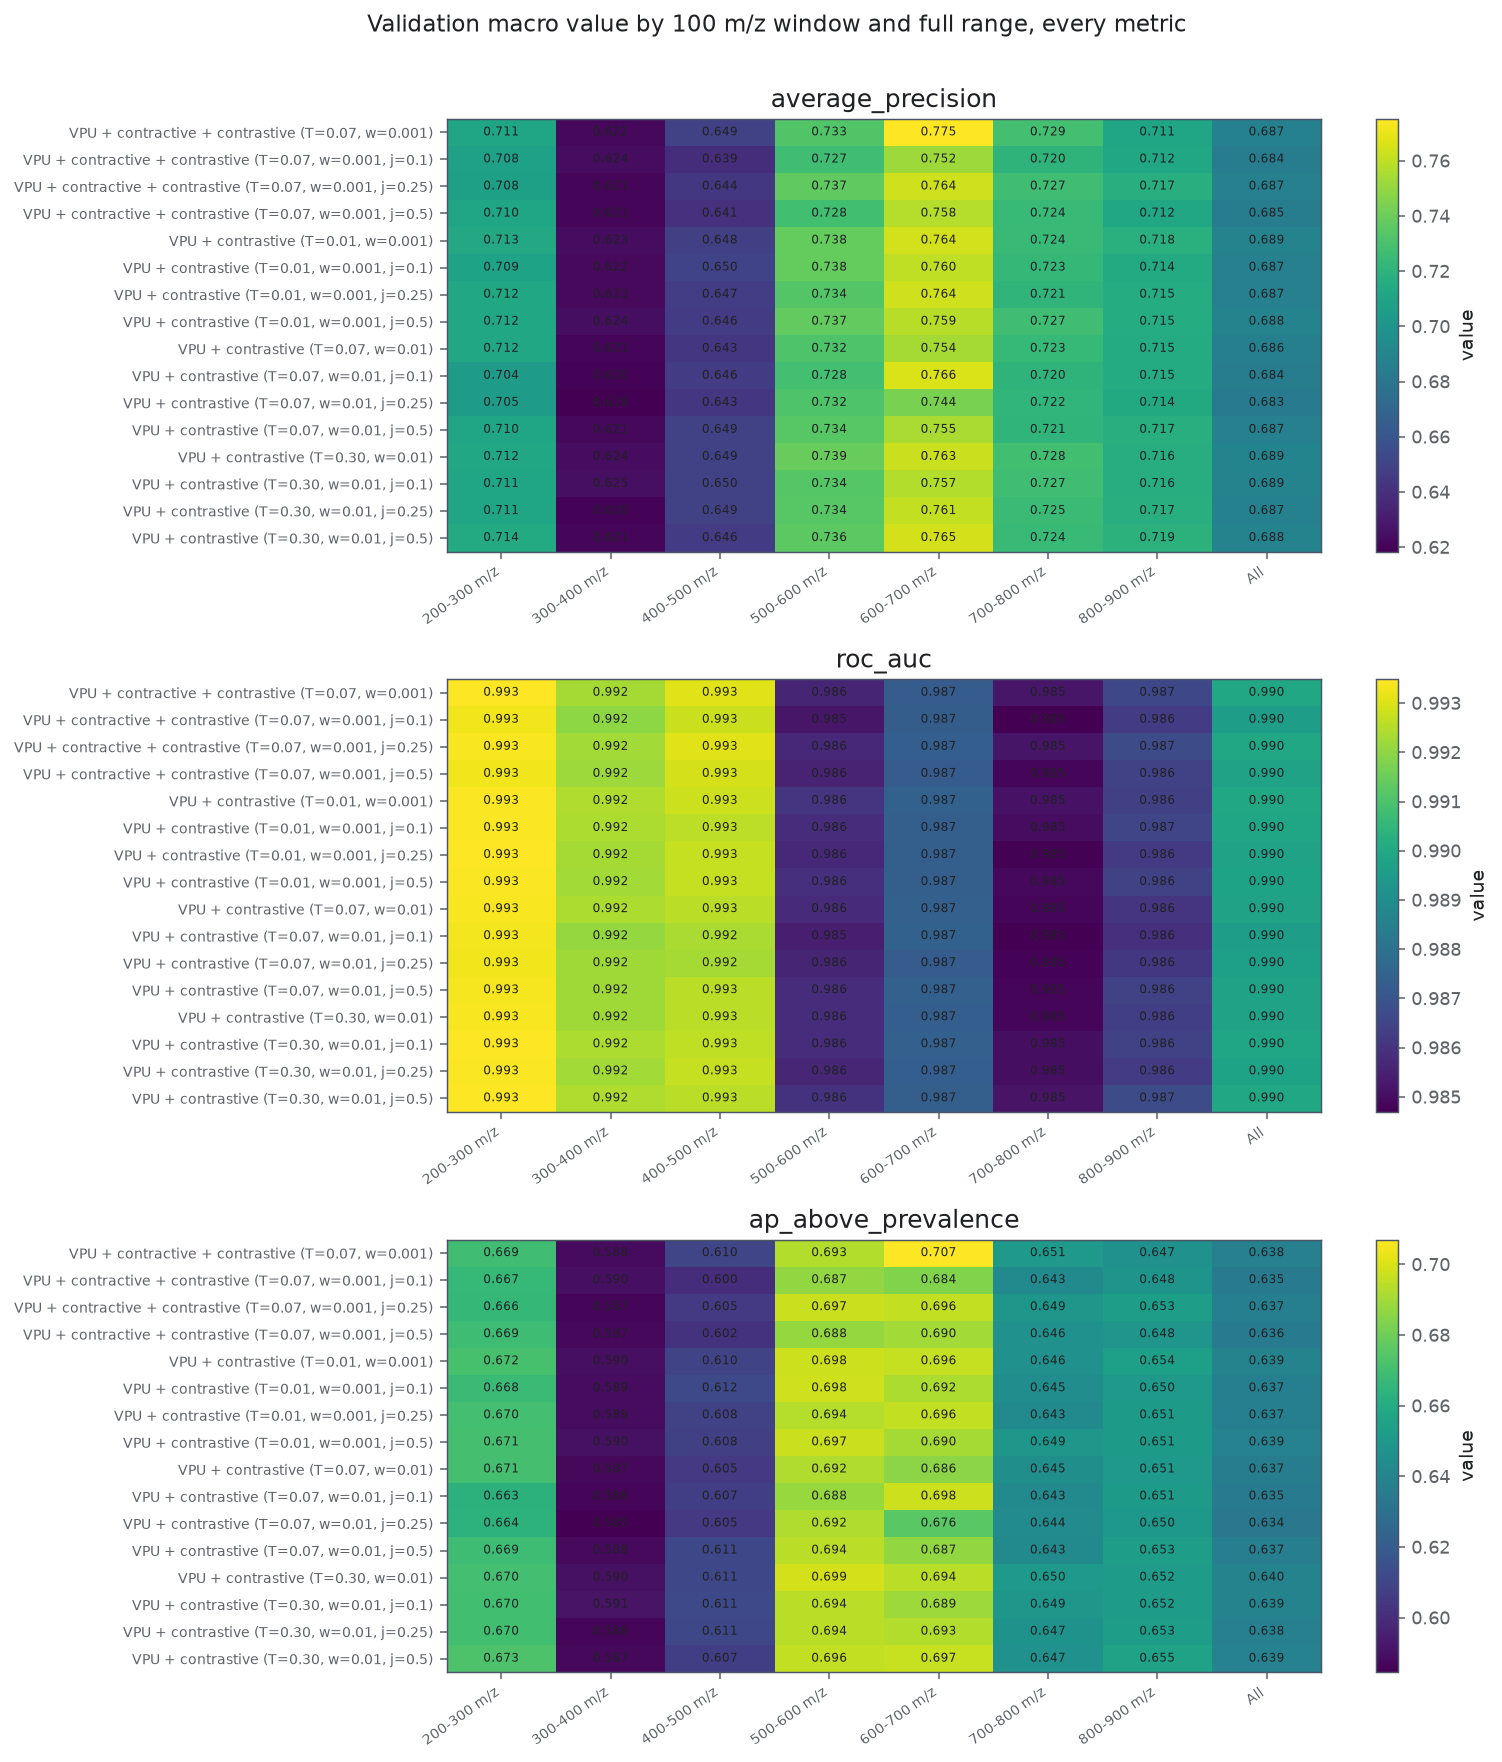

In [7]:
MZ_METRICS = ["average_precision", "roc_auc", "ap_above_prevalence"]

mz_windows = units.query("grouping == 'mz_window' and split == 'validation' and population == 'annotation_retrieval' and metric in @MZ_METRICS")
window_order = sorted(mz_windows.stratum.unique(), key=lambda label: int(label.split("-")[0]))

baseline_labels = models.loc[models["role"] == "baseline", "label"].drop_duplicates().tolist()
baseline_label = baseline_labels[0] if len(baseline_labels) == 1 else None

mz_all = (
    per_class.query("split == 'validation' and population == 'annotation_retrieval' and eligible")
    [["model_id", *MZ_METRICS]]
    .melt(id_vars="model_id", value_vars=MZ_METRICS, var_name="metric", value_name="value")
    .dropna(subset=["value"])
    .groupby(["model_id", "metric"], as_index=False)["value"].mean()
    .merge(models[["model_id", "label", "repetition"]], on="model_id", validate="many_to_one")
    .assign(stratum="All")
)

mz_heatmap = pd.concat([mz_windows, mz_all], ignore_index=True)
column_order = window_order + ["All"]

figure, axes = plt.subplots(len(MZ_METRICS), 1, figsize=(max(11.0, 0.9 * len(column_order) + 4.0), 4.2 * len(MZ_METRICS)), dpi=theme.figure_dpi)

for axis, metric in zip(np.atleast_1d(axes), MZ_METRICS):
    metric_frame = mz_heatmap.query("metric == @metric")
    heatmap_panel(metric_frame, index="label", columns="stratum", values="value", column_order=column_order, ax=axis, title=metric)

    all_values = mz_all.query("metric == @metric").groupby("label")["value"].mean()
    if baseline_label in all_values.index and np.isfinite(all_values.loc[baseline_label]):
        baseline_value = all_values.loc[baseline_label]
        for tick in axis.get_yticklabels():
            label = tick.get_text()
            if label in all_values.index and all_values.loc[label] > baseline_value:
                tick.set_fontweight("bold")

figure.suptitle("Validation macro value by 100 m/z window and full range, every metric", y=0.995, fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.99))
figure.savefig(RESULTS / "mz_window_heatmap.png")

mz_coverage = (
    grouped.query("grouping == 'mz_window' and split == 'validation' and population == 'annotation_retrieval'")
    [["stratum", "total_classes", "eligible_classes"]]
    .drop_duplicates()
    .assign(_order=lambda frame: frame.stratum.map({window: index for index, window in enumerate(window_order)}))
    .sort_values("_order")
    .drop(columns="_order")
)

display(mz_coverage)
reports.save_tables(RESULTS, mz_window_coverage=mz_coverage)

## Detailed stratification: m/z windows, threshold-based metrics

### Methodology

#### Theoretical

Same rationale as the ranking-metric m/z breakdown above, applied to the threshold
family (macro and micro precision/recall/F1, Hamming loss) instead: whether a
threshold-anchored condition's ranking advantage in one part of the m/z axis survives
at a fixed 0.5 cutoff, on every one of the seven threshold metrics rather than one
number.

#### Implementation

Reuses `units` (`grouping == 'mz_window'`) for the per-window values and the base
cache's own pooled `prediction` table (`scope == 'train_supported'`, the same table
`part_4`'s threshold section reads) for the 'All' column, rather than re-pooling the
full-range confusion counts here. Windows are ordered by their lower edge, as above.

#### Figure descriptions

x=window ordered by lower edge, y=condition, cell=validation macro/micro value of that
metric, one panel per threshold metric (`f1`, `precision`, `recall`, `micro_f1`,
`micro_precision`, `micro_recall`, `hamming_loss`), stacked top to bottom. Conditions
`part_4` excludes from the threshold family show an empty row. Bold y-tick label:
better than `vpu_precision_sweep` on the full range (lower for `hamming_loss`, higher
otherwise).

### Remarks

### Notes

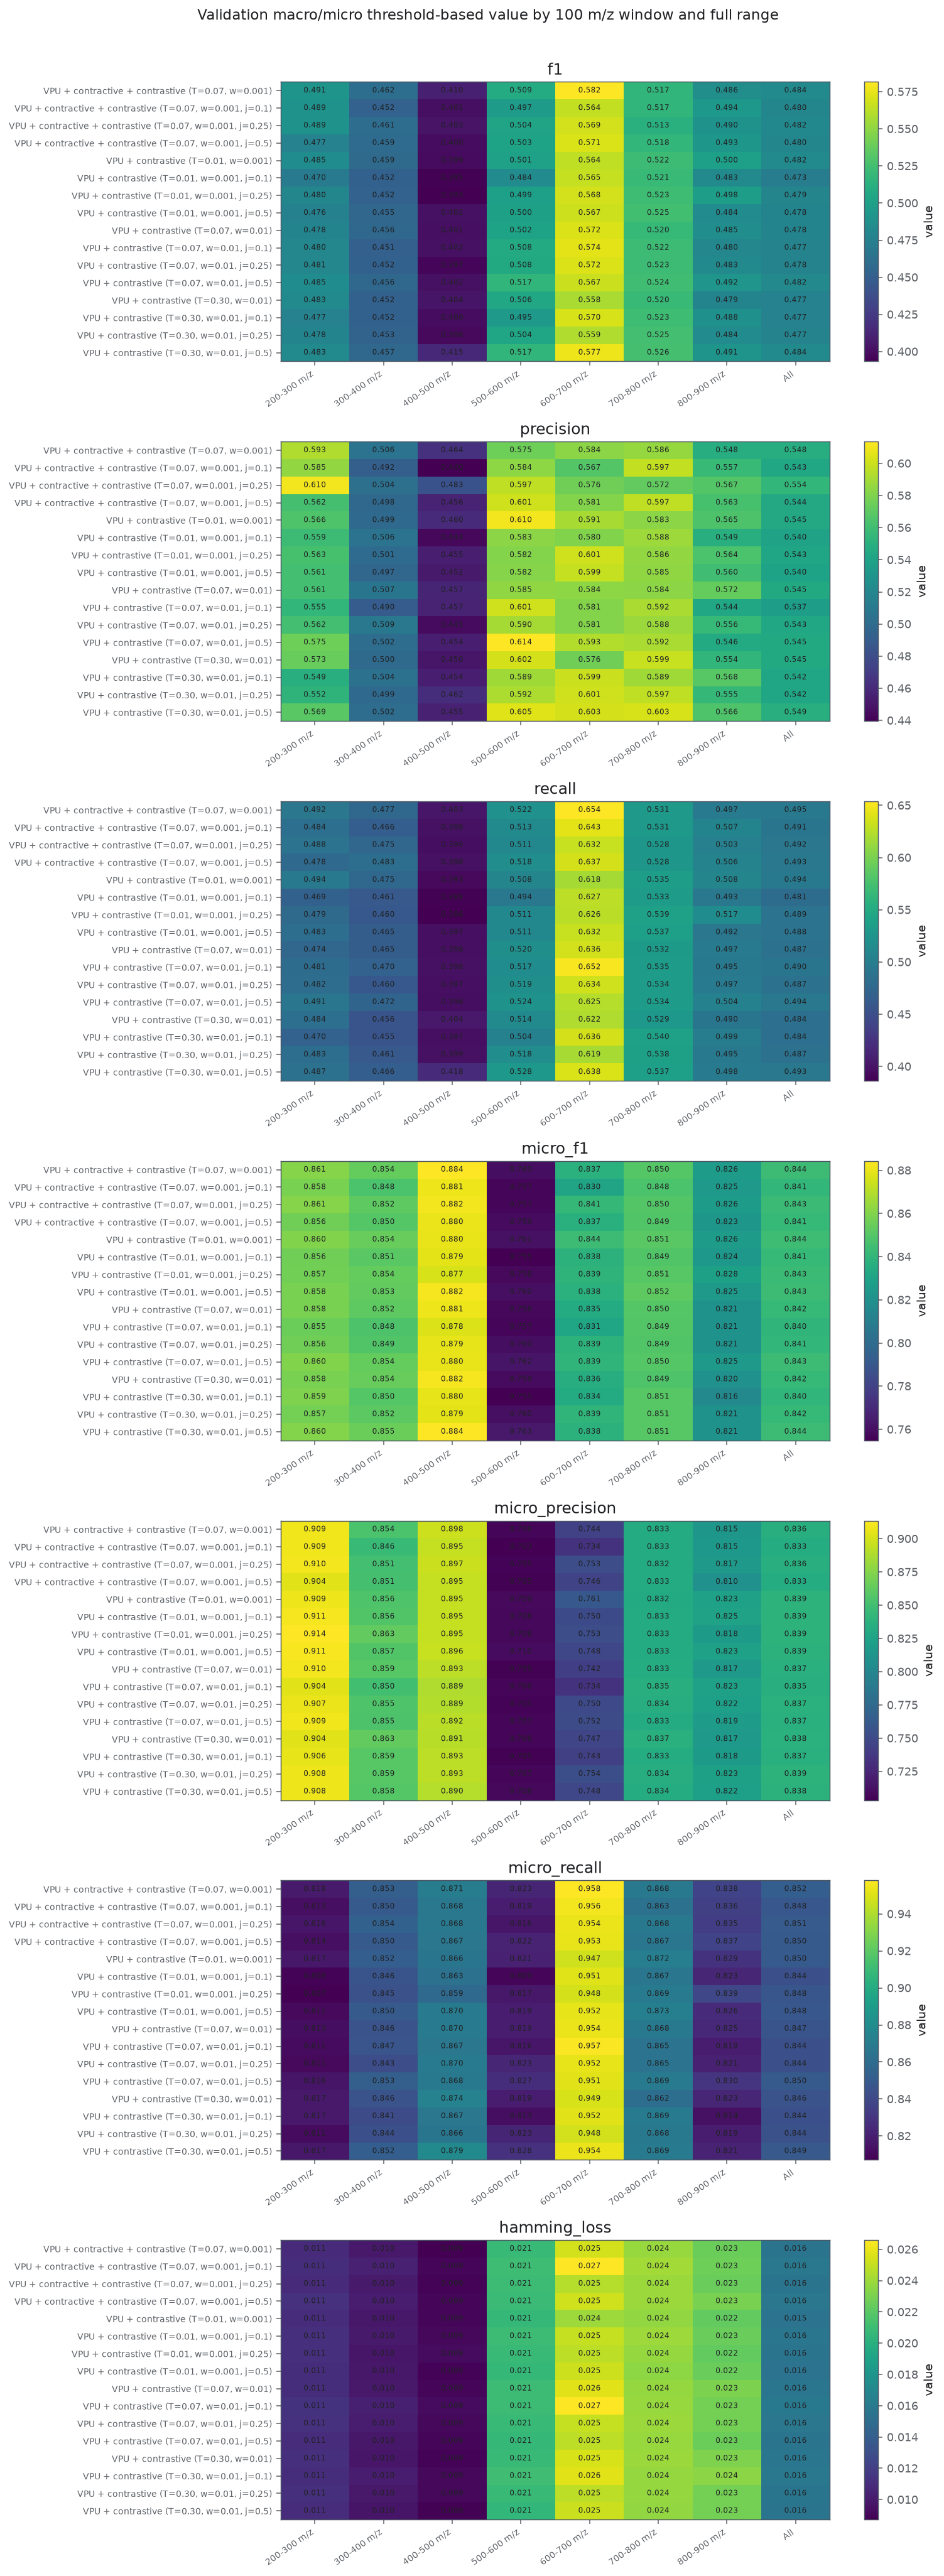

In [8]:
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)
prediction = select_catalog_frame(cache.load_table(settings, "prediction"), models)

mz_windows_threshold = units.query(
    "grouping == 'mz_window' and split == 'validation' and population == 'annotation_retrieval' and metric in @THRESHOLD_METRICS")

threshold_all = (
    prediction.query("split == 'validation' and population == 'annotation_retrieval' and "
                     "scope == 'train_supported' and metric in @THRESHOLD_METRICS")
    .groupby(["label", "metric"], as_index=False).value.mean()
    .assign(stratum="All")
)

threshold_heatmap = pd.concat([mz_windows_threshold[["label", "stratum", "metric", "value"]], threshold_all], ignore_index=True)
threshold_column_order = window_order + ["All"]

figure, axes = plt.subplots(len(THRESHOLD_METRICS), 1,
                            figsize=(max(11.0, 0.9 * len(threshold_column_order) + 4.0), 4.2 * len(THRESHOLD_METRICS)),
                            dpi=theme.figure_dpi)

for axis, metric in zip(np.atleast_1d(axes), THRESHOLD_METRICS):
    metric_frame = threshold_heatmap.query("metric == @metric")
    heatmap_panel(metric_frame, index="label", columns="stratum", values="value", column_order=threshold_column_order, ax=axis, title=metric)

    all_values = threshold_all.query("metric == @metric").set_index("label").value
    if baseline_label in all_values.index and np.isfinite(all_values.loc[baseline_label]):
        baseline_value = all_values.loc[baseline_label]
        for tick in axis.get_yticklabels():
            label = tick.get_text()
            if label in all_values.index and np.isfinite(all_values.loc[label]):
                better = all_values.loc[label] < baseline_value if metric == "hamming_loss" else all_values.loc[label] > baseline_value
                if better:
                    tick.set_fontweight("bold")

figure.suptitle("Validation macro/micro threshold-based value by 100 m/z window and full range", y=0.995, fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.99))
figure.savefig(RESULTS / "mz_window_heatmap_threshold.png")

## Detailed stratification: evidence regime, on every metric

### Methodology

#### Theoretical

Whether prediction quality differs between rare, common and (if present) undetectable
ions, on every ranking metric, for the same reason as the m/z breakdown above.

#### Implementation

Reuses `units` from above. Regimes are ordered undetectable/rare/common, the same
order used by `class_strata`. One panel per metric, stacked vertically; within a panel,
one violin per regime.

#### Figure descriptions

x=regime, y=validation value of that metric, one panel per metric, stacked top to
bottom in one figure.

### Remarks

### Notes

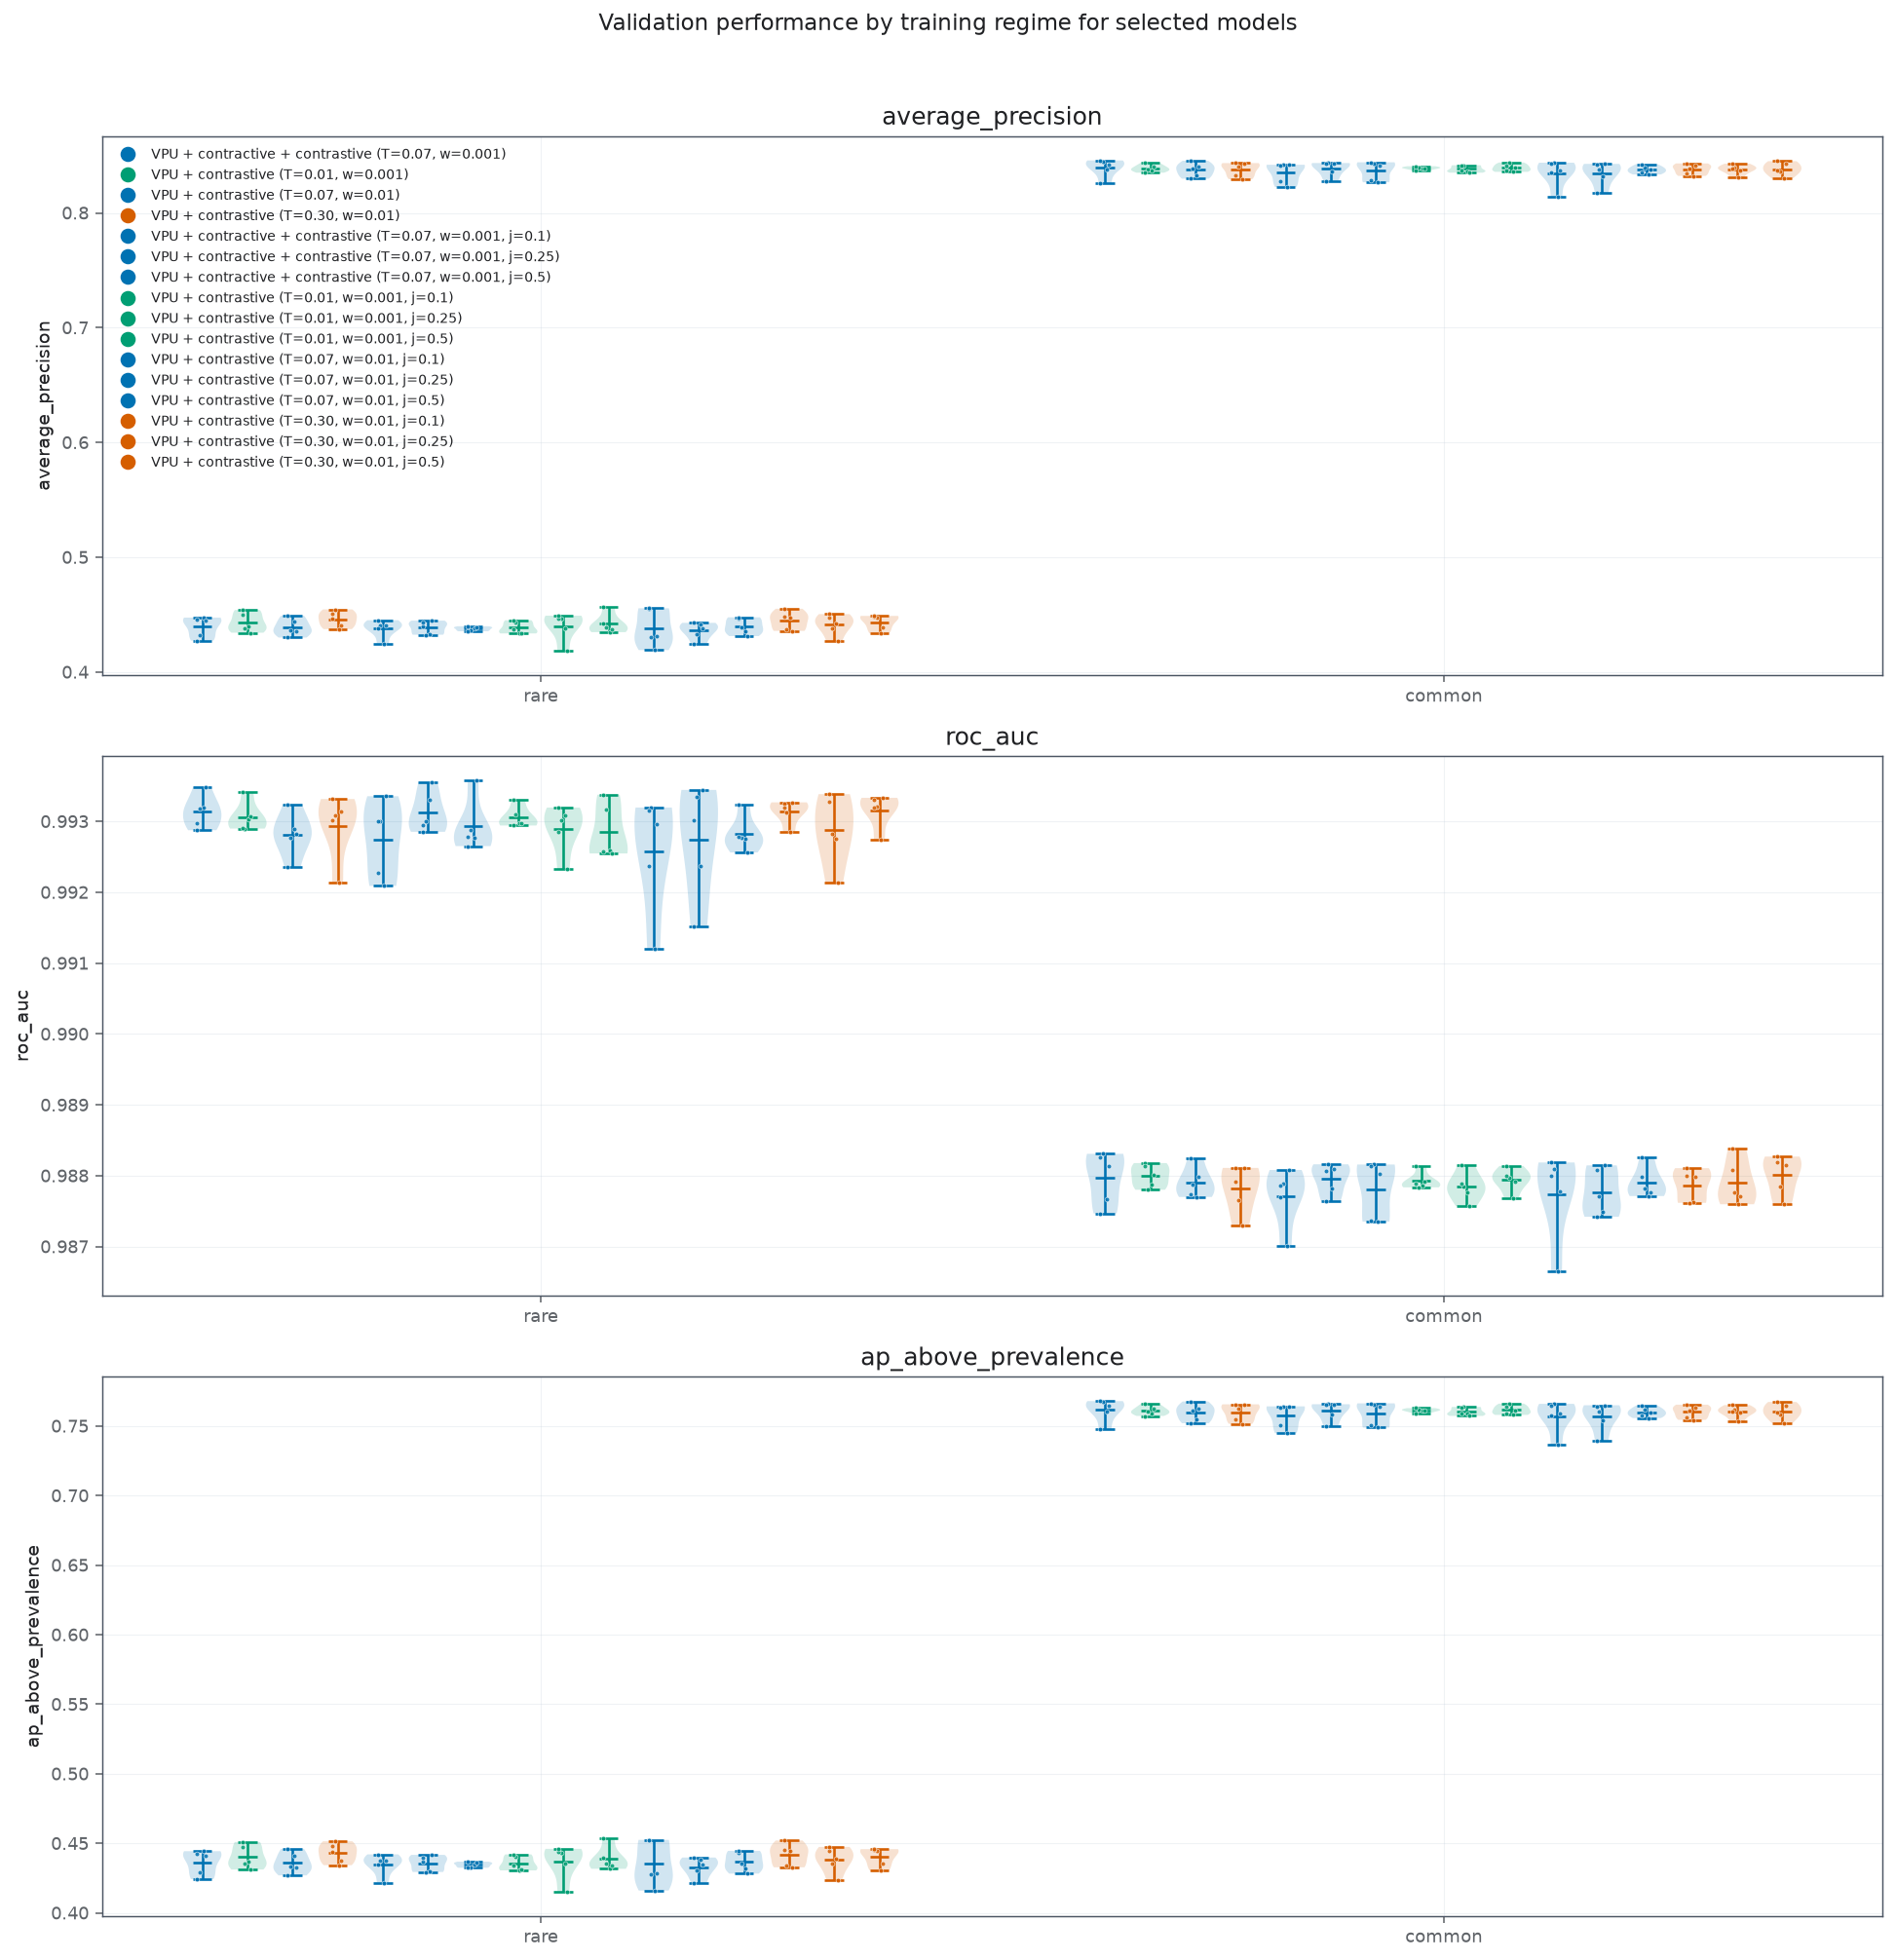

In [9]:
MZ_METRICS = ["average_precision", "roc_auc", "ap_above_prevalence"]

selected_labels = CONDITION_ORDER
baseline_labels = models.loc[models["role"] == "baseline", "label"].drop_duplicates().tolist()
baseline_label = baseline_labels[0] if len(baseline_labels) == 1 else None

regime = units.query(
    "grouping == 'train_regime' and split == 'validation' and "
    "population == 'annotation_retrieval' and metric in @MZ_METRICS and label in @selected_labels"
)

REGIME_ORDER = [name for name in ["undetectable", "rare", "common"] if name in set(regime.stratum)]

figure, axes = plt.subplots(len(MZ_METRICS), 1, figsize=(14.0, 4.8 * len(MZ_METRICS)), dpi=theme.figure_dpi)

group_width = 0.8
violin_width = group_width / len(selected_labels)

for axis, metric in zip(np.atleast_1d(axes), MZ_METRICS):
    metric_frame = regime.query("metric == @metric")

    for regime_position, regime_name in enumerate(REGIME_ORDER):
        baseline_values = metric_frame.query("stratum == @regime_name and label == @baseline_label")["value"].dropna().to_numpy()

        for model_index, label in enumerate(selected_labels):
            values = metric_frame.query("stratum == @regime_name and label == @label")["value"].dropna().to_numpy()
            if not len(values):
                continue

            position = regime_position - group_width / 2 + violin_width / 2 + model_index * violin_width

            plot_violin_with_points(
                values,
                position=position,
                ax=axis,
                width=violin_width * 0.85,
                color=LABEL_COLOR[label],
                point_size=6.0,
                jitter=violin_width * 0.12,
                theme=theme,
            )

        if baseline_label is not None and len(baseline_values):
            baseline_median = np.median(baseline_values)
            axis.hlines(
                baseline_median,
                regime_position - group_width / 2,
                regime_position + group_width / 2,
                color="black",
                linestyle="--",
                linewidth=1.3,
            )

    axis.set_xticks(range(len(REGIME_ORDER)))
    axis.set_xticklabels(REGIME_ORDER, fontsize=9)
    axis.set(ylabel=metric, title=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=LABEL_COLOR[label], markersize=7, label=label)
    for label in selected_labels
]

if baseline_label is not None:
    handles.append(
        plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.3, label=f"{baseline_label} median")
    )

axes[0].legend(handles=handles, fontsize=7, frameon=theme.legend_frame, loc="best")

figure.suptitle("Validation performance by training regime for selected models", y=0.995, fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.98))
figure.savefig(RESULTS / "regime_selected_models_violin.png")

## Detailed stratification: evidence regime, threshold-based metrics

### Methodology

#### Theoretical

Same rationale as the ranking-metric regime breakdown above, for the threshold family
instead: whether a threshold-anchored condition's macro/micro precision, recall, F1
and Hamming loss differ between rare, common and (if present) undetectable ions, the
same way its ranking metrics do.

#### Implementation

Reuses `selected_labels`, `baseline_label`, `REGIME_ORDER` and the group/violin
geometry from the cell above; all four selected model prefixes are threshold-anchored
families (`part_4`), so no panel is empty by construction. One panel per threshold
metric, stacked vertically; within a panel, one violin per regime.

#### Figure descriptions

x=regime, y=validation value of that metric, one panel per threshold metric, stacked
top to bottom in one figure.

### Remarks

### Notes

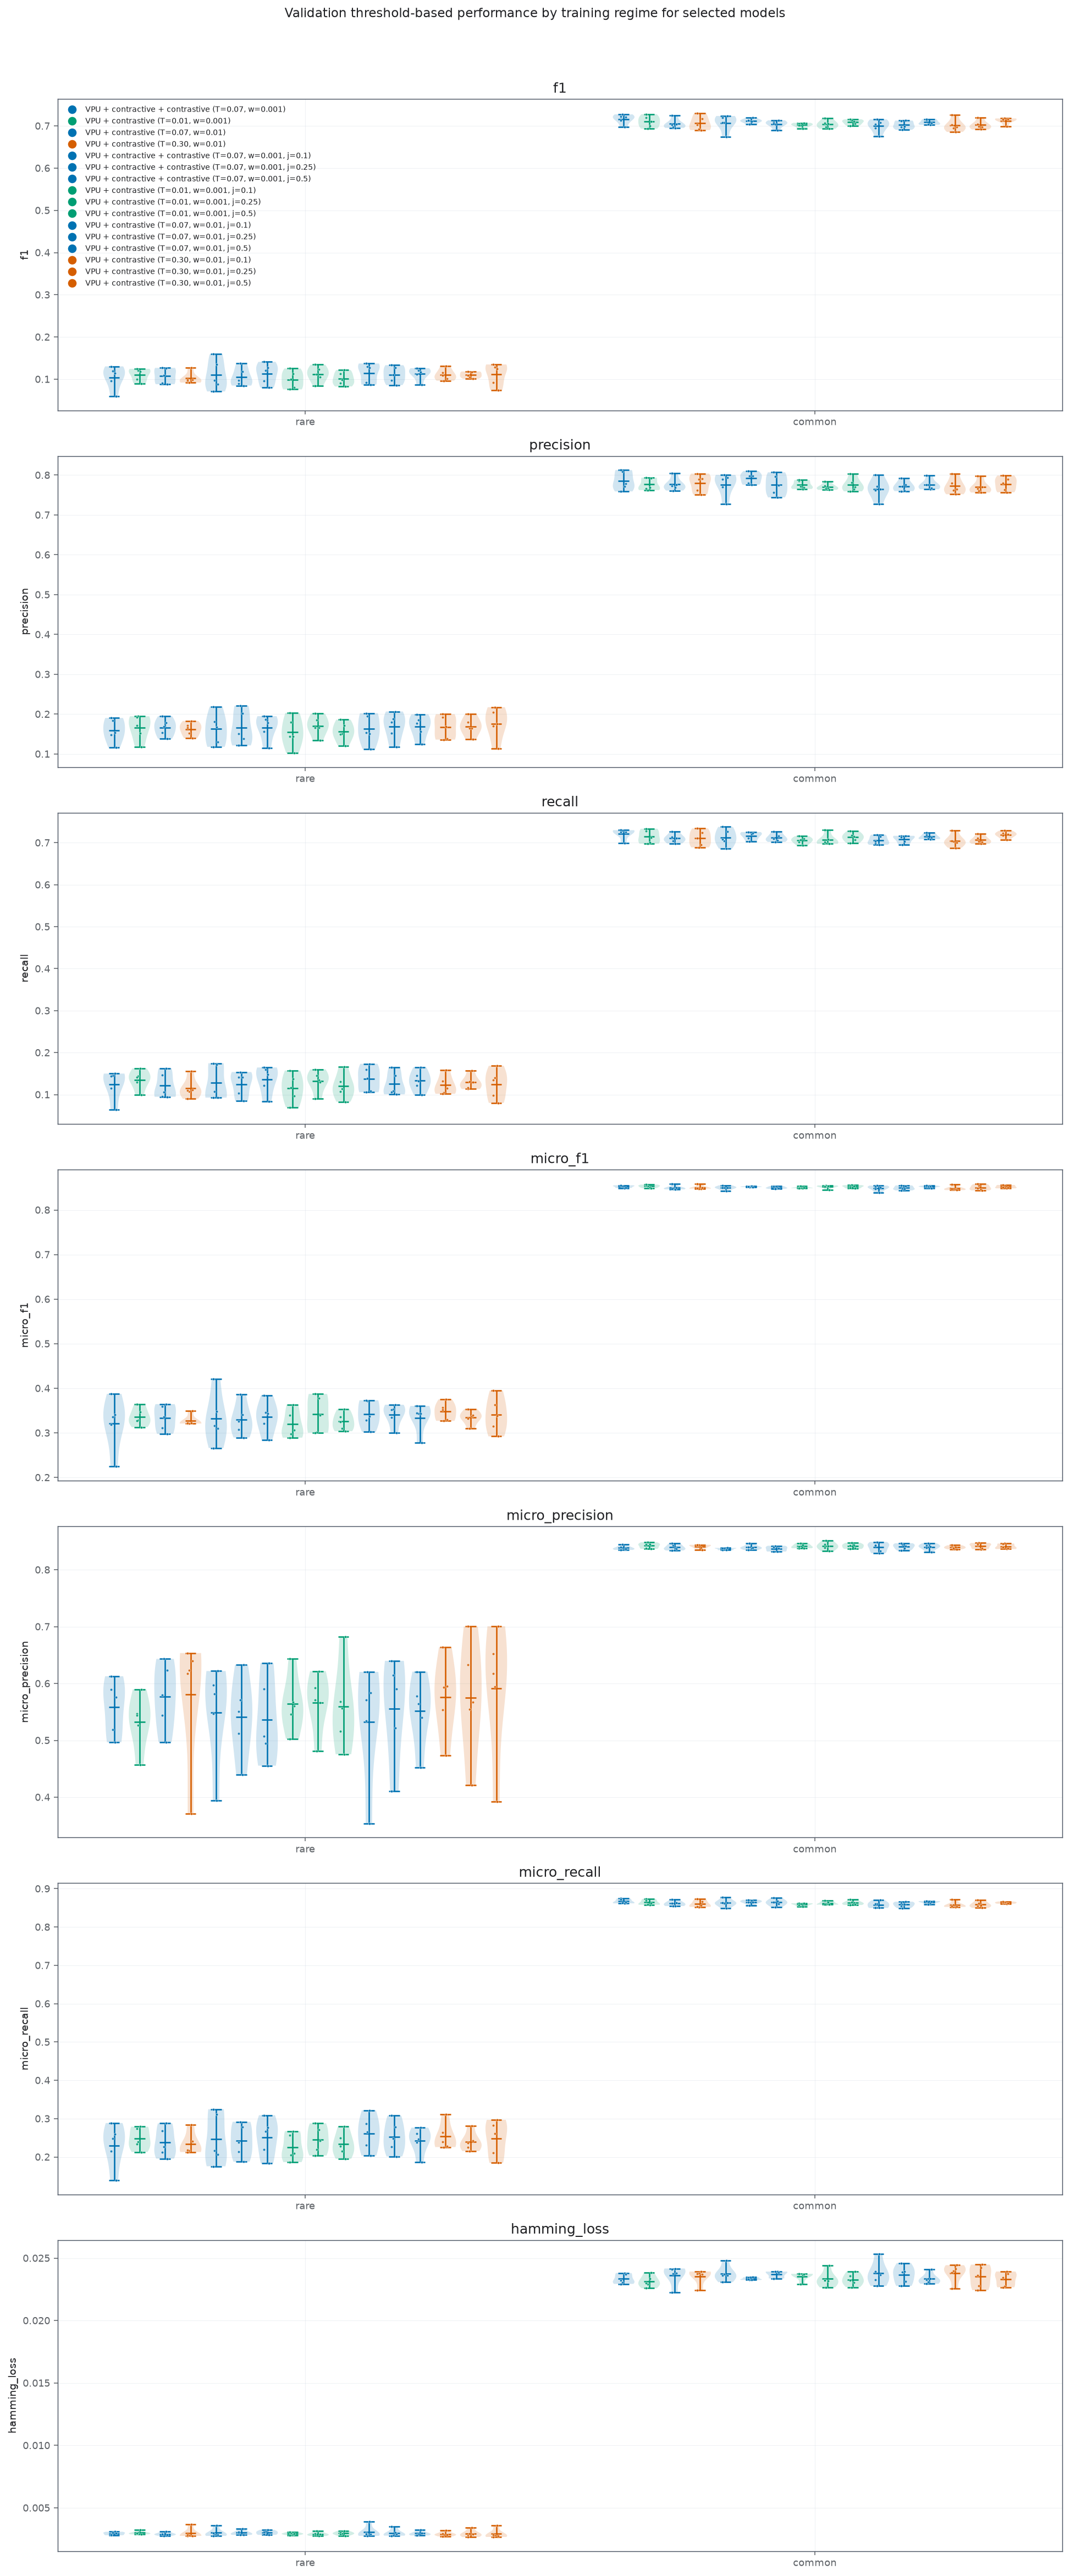

In [10]:
regime_threshold = units.query(
    "grouping == 'train_regime' and split == 'validation' and "
    "population == 'annotation_retrieval' and metric in @THRESHOLD_METRICS and label in @selected_labels"
)

figure, axes = plt.subplots(len(THRESHOLD_METRICS), 1, figsize=(14.0, 4.8 * len(THRESHOLD_METRICS)), dpi=theme.figure_dpi)

for axis, metric in zip(np.atleast_1d(axes), THRESHOLD_METRICS):
    metric_frame = regime_threshold.query("metric == @metric")

    for regime_position, regime_name in enumerate(REGIME_ORDER):
        baseline_values = metric_frame.query("stratum == @regime_name and label == @baseline_label")["value"].dropna().to_numpy()

        for model_index, label in enumerate(selected_labels):
            values = metric_frame.query("stratum == @regime_name and label == @label")["value"].dropna().to_numpy()
            if not len(values):
                continue

            position = regime_position - group_width / 2 + violin_width / 2 + model_index * violin_width

            plot_violin_with_points(
                values,
                position=position,
                ax=axis,
                width=violin_width * 0.85,
                color=LABEL_COLOR[label],
                point_size=6.0,
                jitter=violin_width * 0.12,
                theme=theme,
            )

        if baseline_label is not None and len(baseline_values):
            baseline_median = np.median(baseline_values)
            axis.hlines(
                baseline_median,
                regime_position - group_width / 2,
                regime_position + group_width / 2,
                color="black",
                linestyle="--",
                linewidth=1.3,
            )

    axis.set_xticks(range(len(REGIME_ORDER)))
    axis.set_xticklabels(REGIME_ORDER, fontsize=9)
    axis.set(ylabel=metric, title=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)

axes[0].legend(handles=handles, fontsize=7, frameon=theme.legend_frame, loc="best")

figure.suptitle("Validation threshold-based performance by training regime for selected models", y=0.995, fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.98))
figure.savefig(RESULTS / "regime_selected_models_threshold_violin.png")

## Detailed stratification: group cardinality

### Methodology

#### Theoretical

Which group sizes the reported means actually rest on, read from the smallest class
count first, since a mean over a handful of classes and a mean over hundreds are not
the same kind of evidence even when both are called "macro AP" — reading cardinality
first turns a stratified mean into an outlier search rather than a second aggregate.

#### Implementation

Ordered by `eligible_classes` ascending, so the least-supported stratum is the first
row rather than the last.

#### Figure descriptions

One row per `train_support` stratum, ordered by ascending `eligible_classes`, with the
mean and across-seed standard deviation of validation average precision next to the
class count it is computed from.

### Remarks

### Notes

In [11]:
cardinality = (units.query("grouping == 'train_support' and split == 'validation' and "
                           "population == 'annotation_retrieval' and metric == 'average_precision'")
              .groupby("stratum").value.agg(mean="mean", std="std", seeds="count").reset_index())
# `population` pinned for the same reason as `mz_coverage` above.
support_coverage = (grouped.query("grouping == 'train_support' and split == 'validation' and population == 'annotation_retrieval'")
                    [["stratum", "total_classes", "eligible_classes"]].drop_duplicates())
cardinality = cardinality.merge(support_coverage, on="stratum", validate="one_to_one").sort_values("eligible_classes")
display(cardinality)
reports.save_tables(RESULTS, cardinality_summary=cardinality)

,stratum,mean,std,seeds,total_classes,eligible_classes
0,1-9 positives,0.211227,0.028065,80,36,36
1,10-99 positives,0.322867,0.010036,80,85,85
2,100+ positives,0.810826,0.006454,80,387,387


2026-09-19 23:46:01,818 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:345 | Saved 1 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/part_6_prediction_local_results.


## Generalization gap on common classes

### Methodology

#### Theoretical

`part_4`'s own generalization-gap section pairs training and evaluation *macro* average
precision per condition. This section asks the same question per class: for the
classes eligible in both the training and a held-out partition, does the gap
concentrate in specific classes or spread evenly? A per-class view answers a question
the macro gap cannot: whether a shrinking macro gap reflects every class improving a
little or a few classes improving a lot while the rest stay wide.

#### Implementation

`generalization_gaps` restricts to classes eligible in both the training and held-out
partition for the same model and population, so an apparent gap caused by different
class sets is excluded; positive prevalence may still differ between the two.

#### Figure descriptions

Per condition, the distribution across matched classes of the train-minus-held-out
difference in average precision (validation as the held-out partition); a positive gap
means higher train performance, but a small gap alone does not establish good quality.

### Remarks

### Notes

,model_id,population,held_out,metric,classes,train_value,held_out_value,value,label
0,vpu_contractive_interaction_expanded/task_000020,annotation_retrieval,validation,average_precision,508,0.663423,0.686281,-0.022858,"VPU + contrastive (T=0.01, w=0.001)"
1,vpu_contractive_interaction_expanded/task_000020,annotation_retrieval,validation,roc_auc,508,0.990498,0.989830,0.000668,"VPU + contrastive (T=0.01, w=0.001)"
2,vpu_contractive_interaction_expanded/task_000020,annotation_retrieval,test,average_precision,508,0.663423,0.668768,-0.005345,"VPU + contrastive (T=0.01, w=0.001)"
3,vpu_contractive_interaction_expanded/task_000020,annotation_retrieval,test,roc_auc,508,0.990498,0.988847,0.001651,"VPU + contrastive (T=0.01, w=0.001)"
4,vpu_contractive_interaction_expanded/task_000020,operational_pn,validation,average_precision,508,0.846758,0.860577,-0.013819,"VPU + contrastive (T=0.01, w=0.001)"
...,...,...,...,...,...,...,...,...,...
635,vpu_jaccard_shortlist/task_000059,annotation_retrieval,test,roc_auc,508,0.990748,0.989750,0.000998,"VPU + contractive + contrastive (T=0.07, w=0.0..."
636,vpu_jaccard_shortlist/task_000059,operational_pn,validation,average_precision,508,0.853757,0.861091,-0.007334,"VPU + contractive + contrastive (T=0.07, w=0.0..."
637,vpu_jaccard_shortlist/task_000059,operational_pn,validation,roc_auc,508,0.995361,0.994491,0.000870,"VPU + contractive + contrastive (T=0.07, w=0.0..."
638,vpu_jaccard_shortlist/task_000059,operational_pn,test,average_precision,508,0.853757,0.861331,-0.007575,"VPU + contractive + contrastive (T=0.07, w=0.0..."


2026-09-19 23:46:04,312 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:345 | Saved 1 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/part_6_prediction_local_results.


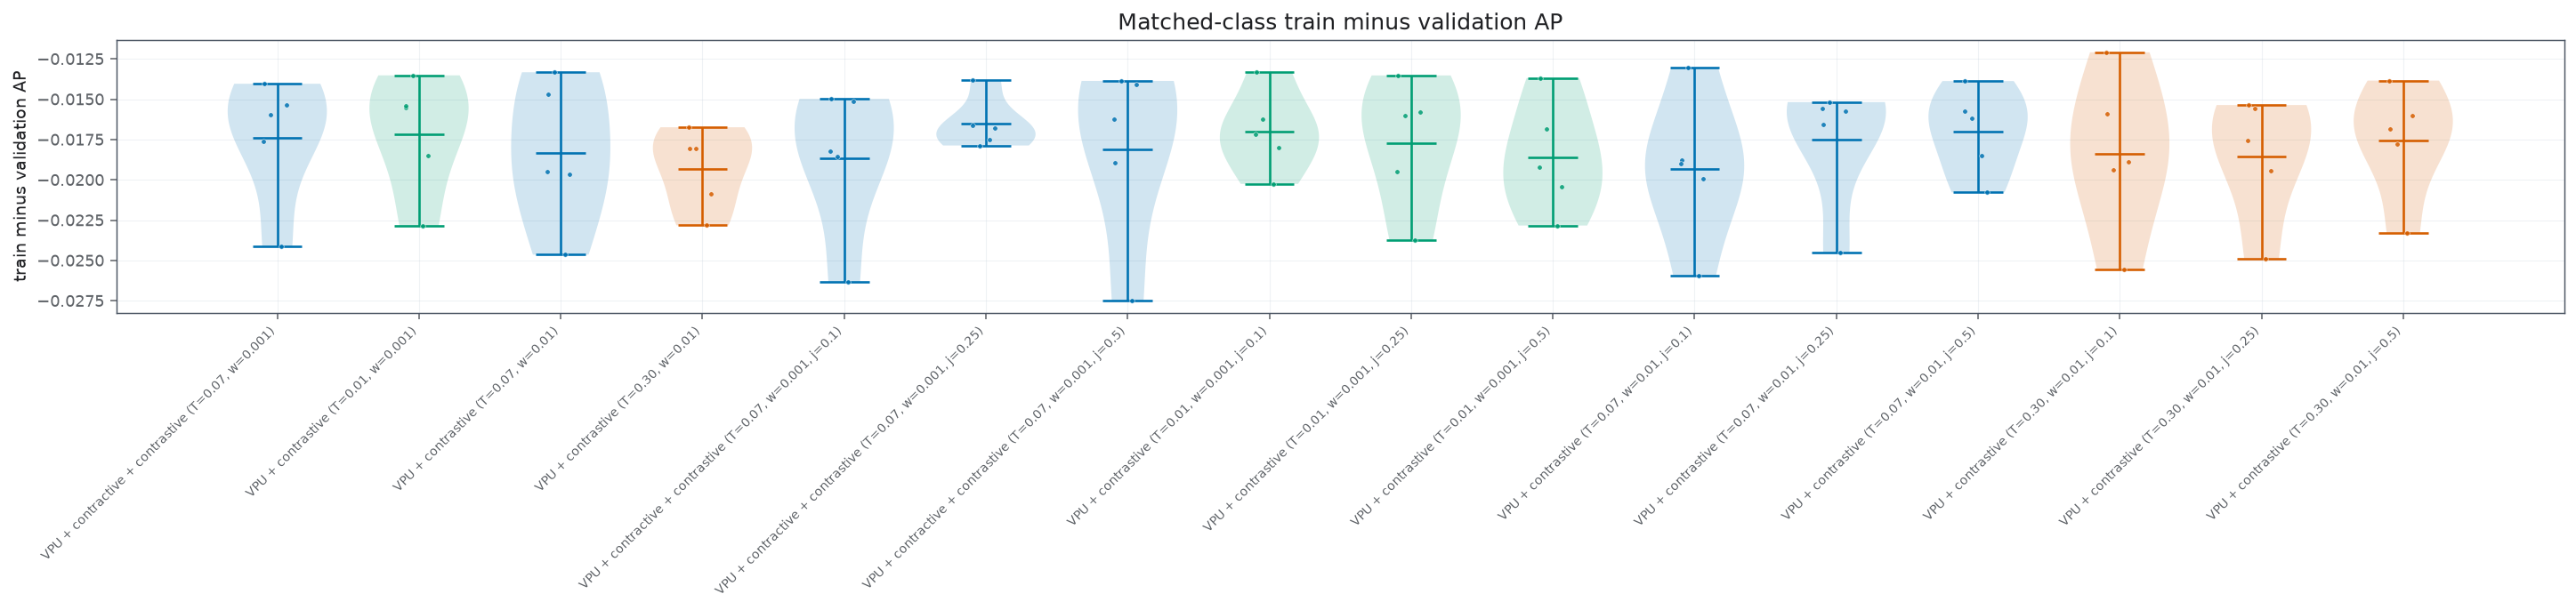

In [12]:
gaps = generalization_gaps(per_class)
gaps = gaps.merge(models[["model_id", "label"]], on="model_id", validate="many_to_one")
display(gaps)

gap_selected = gaps.query("held_out == 'validation' and population == 'annotation_retrieval' and metric == 'average_precision'")
figure, axis = plt.subplots(figsize=(max(8.0, 1.3 * len(CONDITION_ORDER)), 5.0), dpi=theme.figure_dpi)
violin_panel(gap_selected, group_column="label", order=CONDITION_ORDER, colors=LABEL_COLOR, ax=axis,
            ylabel="train minus validation AP", title="Matched-class train minus validation AP")
figure.tight_layout()
figure.savefig(RESULTS / "generalization_gap.png")
reports.save_tables(RESULTS, generalization_gaps=gaps)

## Reproducible artifacts

### Methodology

#### Implementation

The base `per_class`/`probe_per_class` tables and their provenance are written by the
base precompute runner, not here; this notebook adds only the strata, stratified
metrics, paired contrasts and generalization-gap tables it derives from them.

### Remarks

### Notes

In [13]:
print("derived tables/figures written:", sorted(path.name for path in RESULTS.glob("*")))

derived tables/figures written: ['baseline_contrasts.csv', 'cardinality_summary.csv', 'class_strata.csv', 'experimental_units.csv', 'generalization_gap.png', 'generalization_gaps.csv', 'grouped_metrics.csv', 'head_probe_comparison.csv', 'mz_window_200-300_m_z.png', 'mz_window_300-400_m_z.png', 'mz_window_400-500_m_z.png', 'mz_window_500-600_m_z.png', 'mz_window_600-700_m_z.png', 'mz_window_700-800_m_z.png', 'mz_window_800-900_m_z.png', 'mz_window_coverage.csv', 'mz_window_heatmap.png', 'mz_window_heatmap_threshold.png', 'paired_differences.csv', 'part0_evidence_separation_0.5_lt_AUC_lt=_0.7.png', 'part0_evidence_separation_AUC_gt_0.7.png', 'part0_evidence_separation_AUC_lt=_0.5.png', 'part0_regime_common.png', 'part0_regime_rare.png', 'per_class_stratified.csv', 'probe_experimental_units.csv', 'probe_grouped_metrics.csv', 'probe_part0_common.png', 'probe_part0_rare.png', 'regime_selected_models_threshold_violin.png', 'regime_selected_models_violin.png', 'regime_transitions.csv', 'split

## Results / Summary

### LLM

Not yet run against the real campaign cache. This notebook has not been executed
against `data/kidney_workspace`; run the base inference cache, then write this section
from the actually observed stratified metrics, m/z/regime breakdowns, cardinality
dependence and generalization gaps before treating any interpretation here as verified.
(The predecessor notebook this was ported from did complete a real run on 2026-09-13
and found cardinality dominating every other effect by roughly an order of magnitude —
worth checking against once this notebook is re-run, but not restated here as
already-verified for this notebook's own, multi-metric structure.)

### Person